=== 500 km Sun-sync design summary ===
Altitude_km                   : 500
Semi_major_axis_km            : 6878.14
Orbital_period_min            : 94.6163
Orbits_per_day                : 15.2194
Orbital_speed_km_s            : 7.61261
Sun_sync_inclination_deg      : 97.4018
Swath_m                       : 1008
GSD_m                         : 6
N_spots                       : 168
Pixel_pitch_um                : 64
Focal_length_m                : 5.33333
IFOV_pix_arcsec               : 2.47518
Computed_GSD_m                : 6
Line_rate_Hz                  : 1268.77
Line_period_ms                : 0.788166
Beam_spot_m                   : 10
Aperture_m                    : 0.052
Airy_diameter_m               : 24.4
Raw_Mbps                      : 2.55784
Compressed_Mbps               : 0.639459
Detector_shape                : 64x4
Detector_pixels_total         : 256

Saved CSV: 500km_custom_design_summary.csv


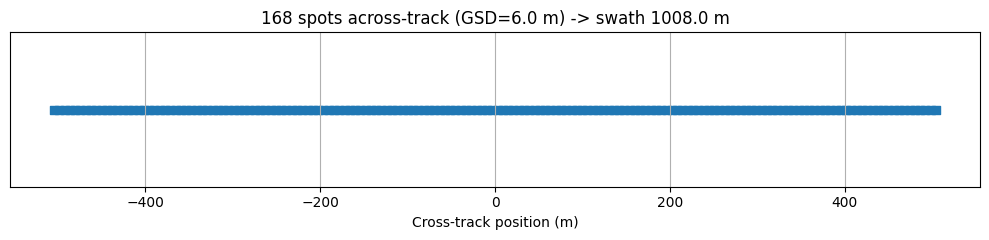

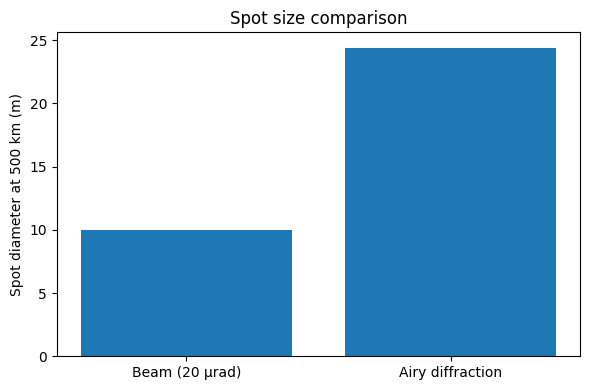

In [9]:
# 500 km Sun-sync design: GSD=6m, 168 spots (1008m swath), beam divergence 20 µrad, lambda=1040 nm
# Pixel pitch = 64 µm. Detector nominal layout: 64 x 4 (interpreted / documented below).

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------
# User inputs
# -------------------------
Re = 6378.137e3                 # Earth radius (m)
mu = 398600.4418e9              # Earth's gravitational parameter (m^3/s^2)
J2 = 1.08262668e-3
deg2rad = math.pi / 180.0
rad2deg = 180.0 / math.pi
seconds_per_day = 86400.0

# Mission inputs
h = 500e3                       # altitude (m)
GSD = 6.0                       # ground sample distance (m/pixel)
N_spots = 168                   # spots across-track
swath_m = 1008.0                # 168 * 6 m

# Detector / pixel
pixel_pitch_um = 64.0           # µm
pixel_pitch_m = pixel_pitch_um * 1e-6
detector_shape = (64, 4)        # layout

# Laser / beam
divergence_rad = 20e-6          # 20 µrad
wavelength_m = 1040e-9          # 1040 nm

# Data assumptions
bits_per_sample = 12
bands = 1
compression_factor = 4.0

# -------------------------
# 1) Orbit parameters
# -------------------------
a = Re + h
n = math.sqrt(mu / a**3)        # mean motion (rad/s)
T = 2.0 * math.pi / n           # orbital period (s)
orbits_per_day = seconds_per_day / T
v_orb = math.sqrt(mu / a)       # orbital speed (m/s)

# Sun-sync inclination
desired_deg_per_day = 360.0 / 365.2422
desired_rad_per_sec = desired_deg_per_day * deg2rad / seconds_per_day
cos_i = - desired_rad_per_sec / (1.5 * J2 * (Re**2 / a**2) * n)
inclination_deg = math.degrees(math.acos(cos_i)) if abs(cos_i) <= 1 else float('nan')

# -------------------------
# 2) Optics
# -------------------------
f_required_m = h * pixel_pitch_m * N_spots / swath_m
IFOV_pix_rad = pixel_pitch_m / f_required_m
IFOV_pix_arcsec = IFOV_pix_rad * rad2deg * 3600.0
computed_GSD = h * pixel_pitch_m / f_required_m

# -------------------------
# 3) Line rate
# -------------------------
line_rate_Hz = v_orb / GSD
line_period_s = 1.0 / line_rate_Hz

# -------------------------
# 4) Beam & aperture
# -------------------------
beam_spot_m = divergence_rad * h
aperture_required_m = wavelength_m / divergence_rad
airy_radius_rad = 1.22 * wavelength_m / aperture_required_m
airy_diameter_m = 2 * airy_radius_rad * h

# -------------------------
# 5) Data rate
# -------------------------
pixels_per_line = N_spots * bands
raw_bits_per_second = line_rate_Hz * pixels_per_line * bits_per_sample
raw_Mbps = raw_bits_per_second / 1e6
compressed_Mbps = raw_Mbps / compression_factor

# -------------------------
# 6) Summary table
# -------------------------
summary = {
    "Altitude_km": h/1000.0,
    "Semi_major_axis_km": a/1000.0,
    "Orbital_period_min": T/60.0,
    "Orbits_per_day": orbits_per_day,
    "Orbital_speed_km_s": v_orb/1000.0,
    "Sun_sync_inclination_deg": inclination_deg,
    "Swath_m": swath_m,
    "GSD_m": GSD,
    "N_spots": N_spots,
    "Pixel_pitch_um": pixel_pitch_um,
    "Focal_length_m": f_required_m,
    "IFOV_pix_arcsec": IFOV_pix_arcsec,
    "Computed_GSD_m": computed_GSD,
    "Line_rate_Hz": line_rate_Hz,
    "Line_period_ms": line_period_s * 1e3,
    "Beam_spot_m": beam_spot_m,
    "Aperture_m": aperture_required_m,
    "Airy_diameter_m": airy_diameter_m,
    "Raw_Mbps": raw_Mbps,
    "Compressed_Mbps": compressed_Mbps,
    "Detector_shape": f"{detector_shape[0]}x{detector_shape[1]}",
    "Detector_pixels_total": detector_shape[0] * detector_shape[1]
}

df = pd.DataFrame([summary])
csv_path = Path("500km_custom_design_summary.csv")
df.to_csv(csv_path, index=False)

# -------------------------
# 7) Print summary
# -------------------------
print("=== 500 km Sun-sync design summary ===")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k:30s}: {v:.6g}")
    else:
        print(f"{k:30s}: {v}")
print("\nSaved CSV:", csv_path)

# -------------------------
# 8) Plots
# -------------------------
# Plot 1: spots across track
x_positions = np.linspace(-swath_m/2.0, swath_m/2.0, N_spots)
plt.figure(figsize=(10,2.5))
plt.scatter(x_positions, np.zeros_like(x_positions), marker='s')
plt.yticks([])
plt.xlabel("Cross-track position (m)")
plt.title(f"{N_spots} spots across-track (GSD={GSD} m) -> swath {swath_m} m")
plt.grid(axis='x')
plt.tight_layout()
plt.savefig("spots_across_track.png")
plt.show()

# Plot 2: spot size comparison
plt.figure(figsize=(6,4))
labels = ["Beam (20 µrad)", "Airy diffraction"]
values = [beam_spot_m, airy_diameter_m]
plt.bar(labels, values)
plt.ylabel("Spot diameter at 500 km (m)")
plt.title("Spot size comparison")
plt.tight_layout()
plt.savefig("spot_size_comparison.png")
plt.show()


In [3]:
import math

# -------------------------
# Inputs
# -------------------------
h = 500e3             # altitude (m)
GSD = 6.0             # ground sample distance (m)
divergence = 20e-6    # beam divergence (rad)
wavelength = 1040e-9  # wavelength (m)

# -------------------------
# 1. Compute beam spot size
# -------------------------
spot_size = divergence * h  # full footprint diameter on ground

# -------------------------
# 2. Compute required IFOV for 6 m GSD
# -------------------------
IFOV = GSD / h   # radians per pixel
IFOV_µrad = IFOV * 1e6

# -------------------------
# 3. Diffraction-limited aperture diameter
#    (Airy disk: θ = 1.22 * λ / D  ->  D = 1.22 * λ / θ)
# -------------------------
D_required = 1.22 * wavelength / IFOV   # aperture diameter (m)

# -------------------------
# 4. Compare beam vs pixel footprint
# -------------------------
ratio = spot_size / GSD  # how many pixels wide the beam is

# -------------------------
# Print results
# -------------------------
print("---- Imaging / Beam Evaluation ----")
print(f"Altitude: {h/1000:.1f} km")
print(f"GSD: {GSD:.2f} m")
print(f"Beam divergence: {divergence*1e6:.1f} µrad")
print(f"Beam spot size on ground: {spot_size:.2f} m")
print(f"IFOV per pixel: {IFOV_µrad:.2f} µrad")
print(f"Diffraction-limited aperture (for λ={wavelength*1e9:.0f} nm, 6 m GSD): {D_required:.2f} m")
print(f"Beam spot / GSD ratio: {ratio:.2f} pixels")

# -------------------------
# Notes:
# - If beam spot >> GSD, energy spreads over several pixels.
# - Diffraction-limited aperture size gives telescope diameter required
#   to resolve 6 m features at 500 km at 1040 nm.
# -------------------------


---- Imaging / Beam Evaluation ----
Altitude: 500.0 km
GSD: 6.00 m
Beam divergence: 20.0 µrad
Beam spot size on ground: 10.00 m
IFOV per pixel: 12.00 µrad
Diffraction-limited aperture (for λ=1040 nm, 6 m GSD): 0.11 m
Beam spot / GSD ratio: 1.67 pixels


In [2]:
# Sun-synchronous orbit and instrument sizing for fixed GSD
# GSD = 6 m, wavelength = 1040 nm (near-IR), altitude = 500 km
# Author: ChatGPT
# Date: 2025-09-22

import math

# --------------------
# Constants
# --------------------
Re = 6378.137e3            # Earth radius (m)
mu = 398600.4418e9         # m^3/s^2, Earth's GM
h = 500e3                  # orbit altitude (m)
wavelength = 1040e-9       # 1040 nm in meters
GSD = 6.0                  # desired Ground Sample Distance (m)

# --------------------
# Orbital parameters
# --------------------
a = Re + h
n = math.sqrt(mu / a**3)   # mean motion rad/s
T = 2 * math.pi / n        # orbital period (s)
v = math.sqrt(mu / a)      # orbital speed (m/s)

print(f"Orbit altitude: {h/1000:.0f} km")
print(f"Orbital period: {T/60:.2f} min")
print(f"Orbital speed: {v/1000:.3f} km/s")

# --------------------
# IFOV and focal length relation
# --------------------
# IFOV = GSD / h
IFOV_rad = GSD / h
IFOV_arcsec = IFOV_rad * (180/math.pi) * 3600

print(f"\nDesired GSD: {GSD} m")
print(f"Instantaneous FOV (IFOV): {IFOV_rad:.3e} rad = {IFOV_arcsec:.2f} arcsec")

# For a given pixel pitch, required focal length = p / IFOV
pixel_pitches_um = [5, 7, 10, 15]  # typical detector pixel sizes
for p_um in pixel_pitches_um:
    p_m = p_um * 1e-6
    f_req = p_m / IFOV_rad
    print(f" Pixel pitch {p_um:2d} µm -> required focal length f = {f_req:.3f} m")

# --------------------
# Diffraction-limited aperture (Rayleigh criterion)
# --------------------
# Rayleigh angle = 1.22 * λ / D
# Require Rayleigh angle <= IFOV
# -> D >= 1.22 * λ / IFOV
D_req = 1.22 * wavelength / IFOV_rad

print(f"\nAt λ = {wavelength*1e9:.0f} nm:")
print(f" Required aperture diameter for diffraction limit: D >= {D_req:.3f} m")

# --------------------
# Along-track sampling (line rate)
# --------------------
line_rate = v / GSD
print(f"\nRequired line rate (for square pixels): {line_rate:.1f} lines/s")


Orbit altitude: 500 km
Orbital period: 94.62 min
Orbital speed: 7.613 km/s

Desired GSD: 6.0 m
Instantaneous FOV (IFOV): 1.200e-05 rad = 2.48 arcsec
 Pixel pitch  5 µm -> required focal length f = 0.417 m
 Pixel pitch  7 µm -> required focal length f = 0.583 m
 Pixel pitch 10 µm -> required focal length f = 0.833 m
 Pixel pitch 15 µm -> required focal length f = 1.250 m

At λ = 1040 nm:
 Required aperture diameter for diffraction limit: D >= 0.106 m

Required line rate (for square pixels): 1268.8 lines/s
